In [492]:
!pip install pandas numpy matplotlib statsmodels arch pmdarima tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arch

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [493]:
df = pd.read_excel('/content/Price_dataset.xlsx', index_col='Date', parse_dates=True)

In [494]:
df.index = pd.to_datetime(df.index, format='%b-%y')
df = df.asfreq('MS')

In [495]:
df.head()

,Gram,Moong,Arhar
Date,,,
2014-01-01,103.6,126.5,118.1
2014-02-01,101.7,129.3,118.4
2014-03-01,103.5,132.6,119.0
2014-04-01,102.8,135.5,120.6
2014-05-01,103.1,137.8,121.0


In [496]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 147 entries, 2014-01-01 to 2026-03-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gram    147 non-null    float64
 1   Moong   147 non-null    float64
 2   Arhar   147 non-null    float64
dtypes: float64(3)
memory usage: 4.6 KB


In [497]:
data = df['Moong']

# Descriptive statistics

<Axes: xlabel='Date'>

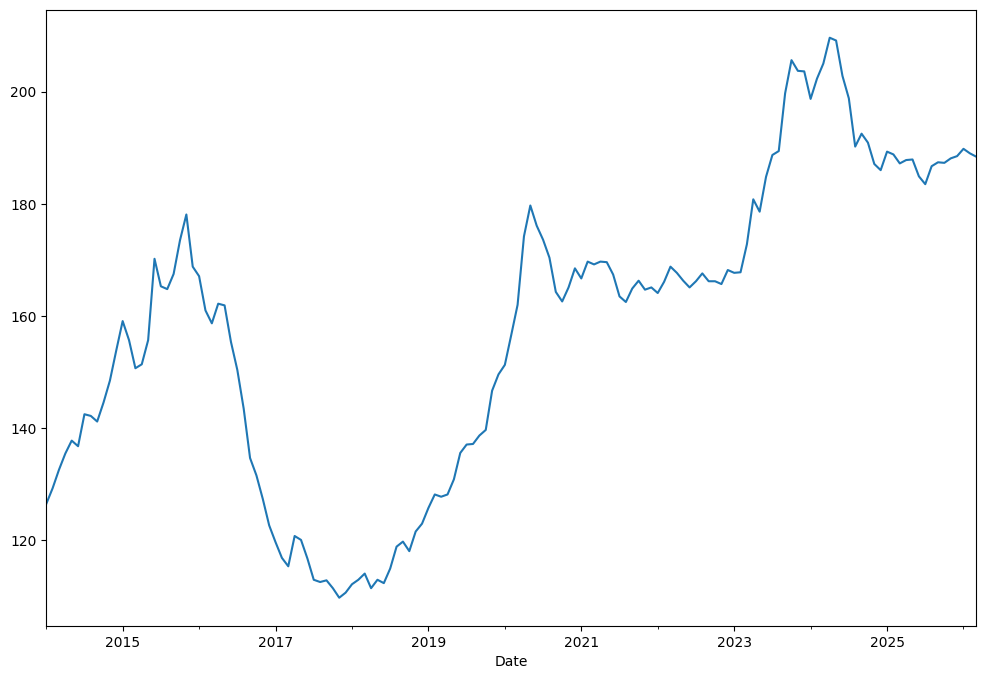

In [498]:
data.plot(figsize=(12,8))

In [499]:
data.describe()

,Moong
count,147.000000
mean,158.093878
std,27.319876
min,109.800000
25%,135.550000
50%,164.800000
75%,178.350000
max,209.600000


In [500]:
data.skew()

np.float64(-0.18367493524905118)

In [501]:
data.kurtosis()

np.float64(-0.9786712766989671)

## Decompose the series

In [502]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [503]:
decompose = seasonal_decompose(data, model='add')

In [504]:
decompose.seasonal

,seasonal
Date,
2014-01-01,-0.931992
2014-02-01,-0.855855
2014-03-01,-0.690325
2014-04-01,1.900205
2014-05-01,2.397554
...,...
2025-11-01,-0.522522
2025-12-01,-0.739946
2026-01-01,-0.931992


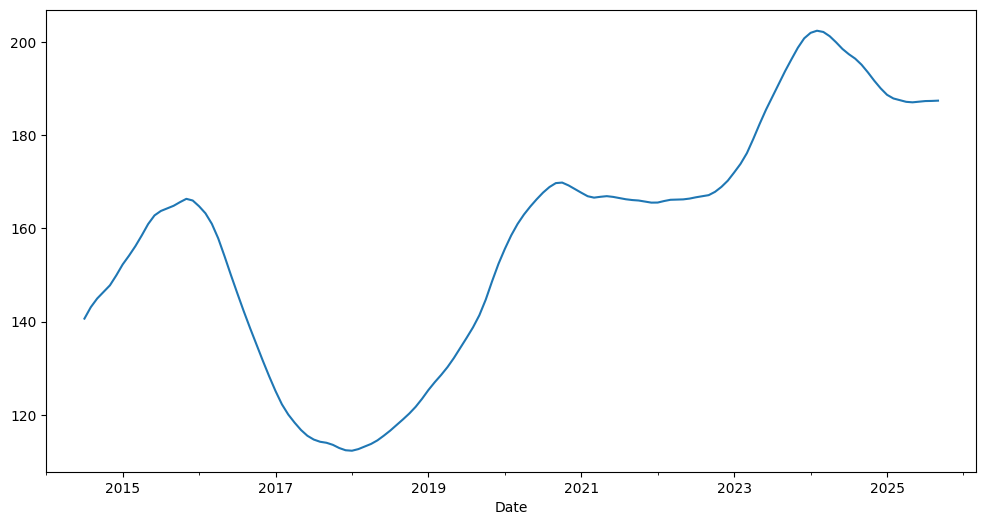

In [505]:
decompose.trend.plot(figsize=(12,6));

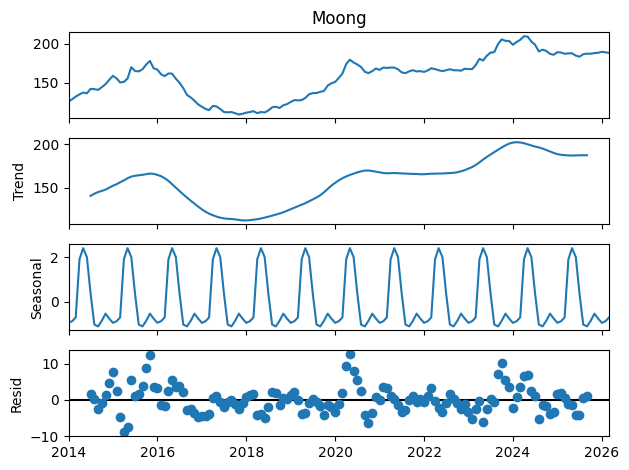

In [506]:
# Plot the decomposition
decompose.plot()
plt.show()

<Axes: >

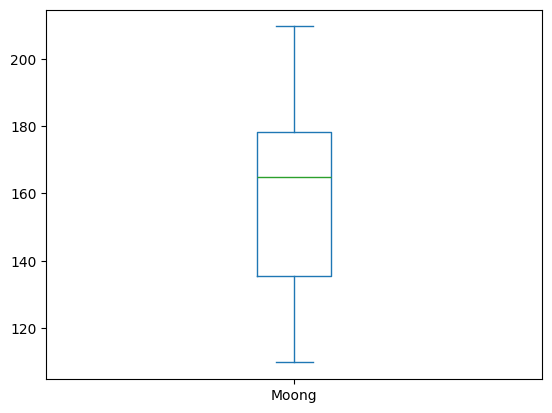

In [507]:
data.plot.box()

# Time series modeling

# Stationarity test

A stationary process has the property that the mean, variance and autocorrelation structure do not change over time.

> $H_0$ : Series is unitroot or non stationary,
>> $H_1$ : Series is stationary

<Axes: xlabel='Date'>

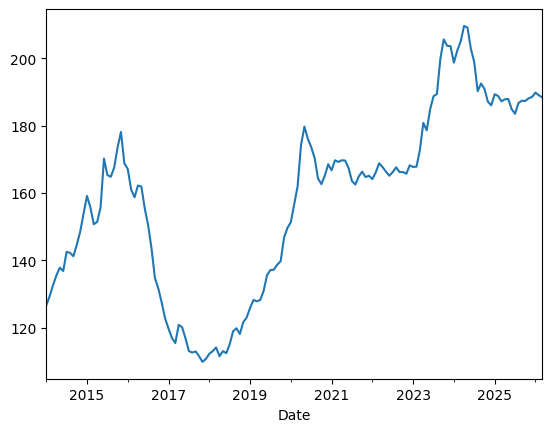

In [508]:
data.plot()

In [509]:
from arch.unitroot import ADF, KPSS, PhillipsPerron

In [510]:
PhillipsPerron(data)

Test Statistic,-1.434
P-value,0.566
Lags,14


In [511]:
ADF(data)

Test Statistic,-1.560
P-value,0.504
Lags,5


#### 1st diff

In [512]:
df_diff = data.diff(periods=1).iloc[1:]

In [513]:
df_diff.head()

,Moong
Date,
2014-02-01,2.8
2014-03-01,3.3
2014-04-01,2.9
2014-05-01,2.3
2014-06-01,-1.0


In [514]:
PhillipsPerron(df_diff)

Test Statistic,-9.021
P-value,0.000
Lags,14


In [515]:
df_diff.head()

,Moong
Date,
2014-02-01,2.8
2014-03-01,3.3
2014-04-01,2.9
2014-05-01,2.3
2014-06-01,-1.0


In [516]:
ADF(df_diff)

Test Statistic,-3.461
P-value,0.009
Lags,4


##### In diff. 1, the data series are in stationary.

<Axes: xlabel='Date'>

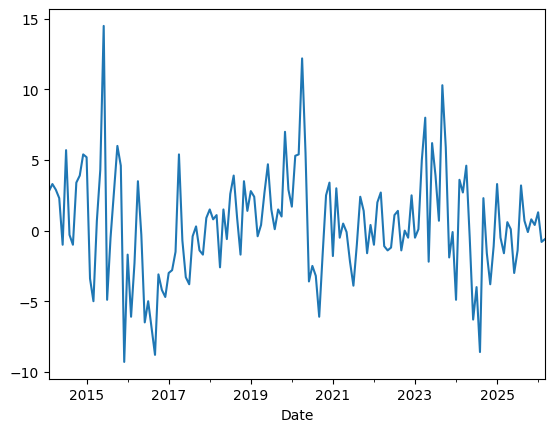

In [517]:
df_diff.plot()

## ACF and PACF plot

>**Autocorrelation** represents the degree of similarity between a given time series and a lagged version of itself over successive time intervals.

> **Partial Autocorrelation** is a conditional correlation.

In [518]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

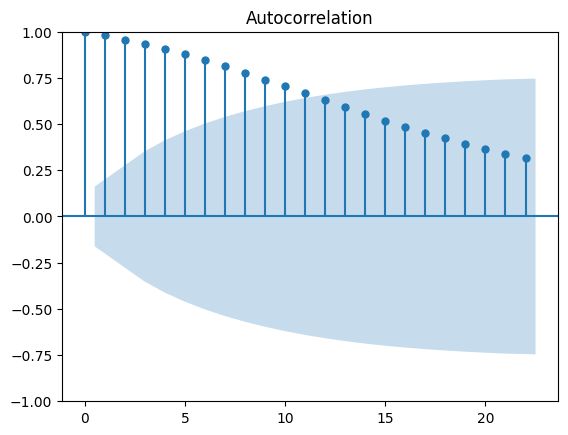

In [519]:
plot_acf(data); # q order

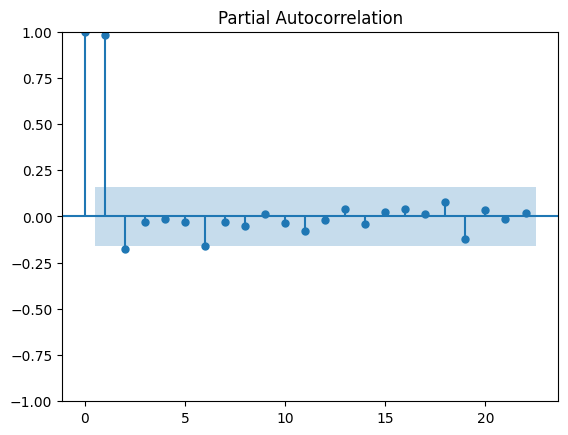

In [520]:
plot_pacf(data); # p order

# AUTO ARIMA

In [521]:
from pmdarima import auto_arima

In [522]:
stepwise_fit = auto_arima(data, start_p=0,start_q=0, max_p=6,max_q=3, m=12, seasonal=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=807.452, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=804.334, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=790.107, Time=0.69 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=791.198, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=804.188, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=788.150, Time=0.05 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=790.097, Time=0.22 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=790.138, Time=0.31 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=790.135, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=789.296, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=789.615, Time=0.65 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=787.080, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=789.050, Time=0.19 sec
 ARIMA(1,1,0)(0,0,1)[12]             

In [523]:
stepwise_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  147
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -391.540
Date:                Mon, 20 Apr 2026   AIC                            787.080
Time:                        20:04:00   BIC                            793.047
Sample:                    01-01-2014   HQIC                           789.504
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3497      0.058      6.067      0.000       0.237       0.463
sigma2        12.4883      1.099     11.364      0.000      10.334      14.642
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                14.52
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.63   Skew:                             0.13
Prob(H) (two-sided):                  0.11   Kurtosis:                         4.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [524]:
from statsmodels.tsa.arima_model import ARIMA, ARIMAResults

In [525]:
from statsmodels.tsa.arima.model import ARIMA

In [526]:
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults

In [527]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 147 entries, 2014-01-01 to 2026-03-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gram    147 non-null    float64
 1   Moong   147 non-null    float64
 2   Arhar   147 non-null    float64
dtypes: float64(3)
memory usage: 4.6 KB


In [528]:
train = df.iloc[:132]
test = df.iloc[132:]

In [529]:
len(test)

15

In [530]:
train.tail()

,Gram,Moong,Arhar
Date,,,
2024-08-01,224.1,190.2,303.8
2024-09-01,232.5,192.5,300.1
2024-10-01,230.6,190.9,290.2
2024-11-01,226.7,187.1,286.9
2024-12-01,221.4,186.0,273.8


In [531]:
test.head()

,Gram,Moong,Arhar
Date,,,
2025-01-01,213.7,189.3,259.1
2025-02-01,207.3,188.8,238.8
2025-03-01,203.2,187.2,229.8
2025-04-01,203.6,187.8,221.8
2025-05-01,199.6,187.9,214.8


## ARIMA Model for Moong


ARIMA(p,d,q)

In [532]:
model_Moong = ARIMA(train['Moong'], order=(1,1,0))

result_Moong = model_Moong.fit()
result_Moong.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Moong   No. Observations:                  132
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -356.717
Date:                Mon, 20 Apr 2026   AIC                            717.434
Time:                        20:04:00   BIC                            723.184
Sample:                    01-01-2014   HQIC                           719.770
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3580      0.062      5.739      0.000       0.236       0.480
sigma2        13.5601      1.311     10.346      0.000      10.991      16.129
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 8.95
Prob(Q):                              0.93   Prob(JB):                         0.01
Heteroskedasticity (H):               0.62   Skew:                             0.10
Prob(H) (two-sided):                  0.12   Kurtosis:                         4.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [533]:
prediction_Moong = result_Moong.predict(start=len(train),end=len(train)+len(test)-1, typ='levels').rename('ARIMA(1,1,0)-predictions')

In [534]:
prediction_Moong

,"ARIMA(1,1,0)-predictions"
2025-01-01,185.606147
2025-02-01,185.465128
2025-03-01,185.414637
2025-04-01,185.396559
2025-05-01,185.390086
2025-06-01,185.387768
2025-07-01,185.386938
2025-08-01,185.386641
2025-09-01,185.386535
2025-10-01,185.386497


In [535]:
test['ARIMA_prediction']= prediction_Moong

<Axes: title={'center': 'True prediction_ARIMA'}, xlabel='Date'>

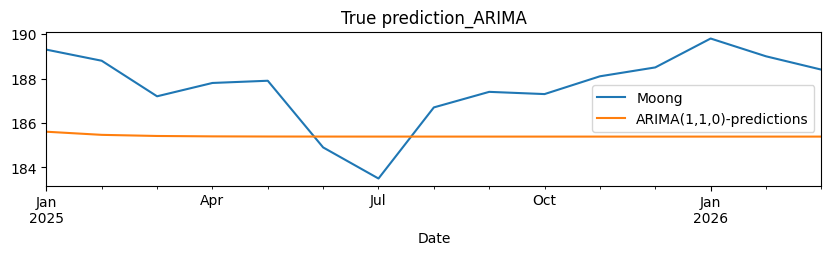

In [536]:
test['Moong'].plot(figsize=(10,2), legend=True, title='True prediction_ARIMA')
prediction_Moong.plot(legend=True)

## Error estimation

In [537]:
from statsmodels.tools.eval_measures import rmse, mse

In [538]:
rmse(test['Moong'],prediction_Moong)

np.float64(2.731834630286254)

In [539]:
mse(test['Moong'],prediction_Moong)

np.float64(7.462920447231235)

In [540]:
test['Moong'].mean()

np.float64(187.64000000000001)

In [541]:
prediction_Moong.mean()

np.float64(185.40928839755873)

# Final Model Forecasting

In [542]:
FinalModel_Moong = ARIMA(data, order=(1,1,0))

FinalResult_Moong = FinalModel_Moong.fit()

In [543]:
FinalResult_Moong.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Moong   No. Observations:                  147
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -391.540
Date:                Mon, 20 Apr 2026   AIC                            787.080
Time:                        20:04:00   BIC                            793.047
Sample:                    01-01-2014   HQIC                           789.504
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3497      0.058      6.067      0.000       0.237       0.463
sigma2        12.4883      1.099     11.364      0.000      10.334      14.642
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                14.52
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.63   Skew:                             0.13
Prob(H) (two-sided):                  0.11   Kurtosis:                         4.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [544]:
forecast_Moong = FinalResult_Moong.predict(start=len(df),end=len(df)+12, typ='levels').rename('ARIMA(1,1,0)-forecast')

<Axes: xlabel='Date'>

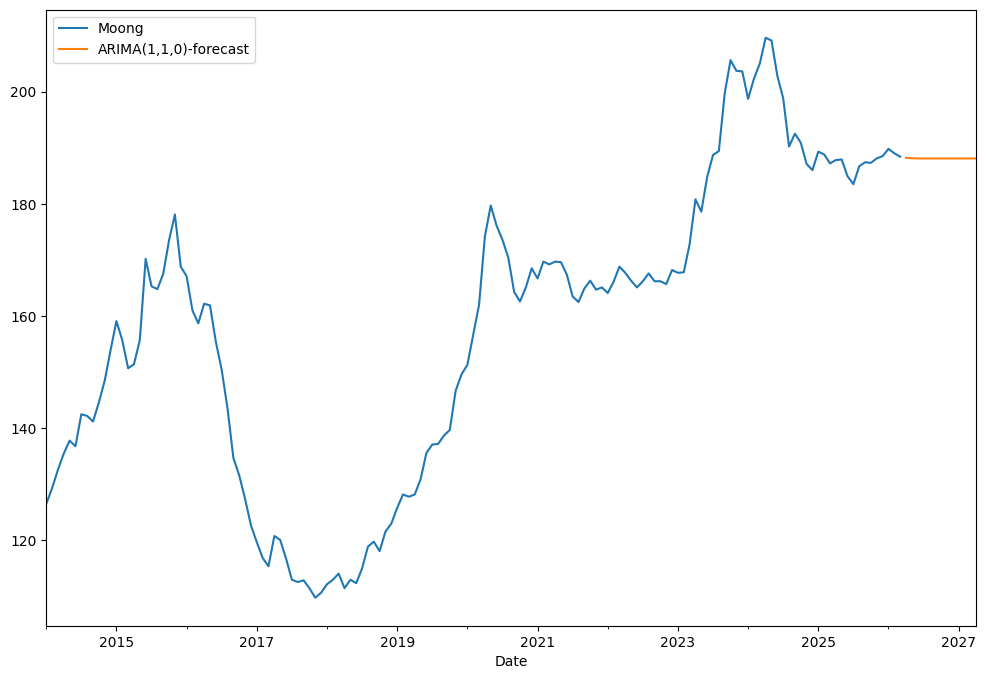

In [545]:
data.plot(figsize=(12,8),legend=True)
forecast_Moong.plot(legend=True)

In [546]:
print(forecast_Moong)

2026-04-01    188.190196
2026-05-01    188.116833
2026-06-01    188.091180
2026-07-01    188.082210
2026-08-01    188.079073
2026-09-01    188.077976
2026-10-01    188.077593
2026-11-01    188.077458
2026-12-01    188.077412
2027-01-01    188.077395
2027-02-01    188.077389
2027-03-01    188.077387
2027-04-01    188.077387
Freq: MS, Name: ARIMA(1,1,0)-forecast, dtype: float64


# Kolmogorov-Smirnov test for goodness of fit. Normality of residuals

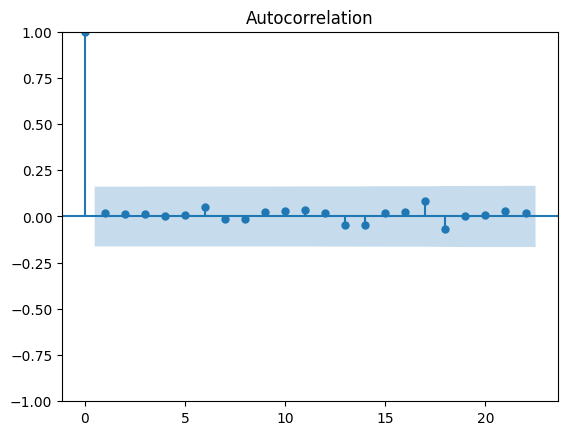

In [547]:
plot_acf(FinalResult_Moong.resid);

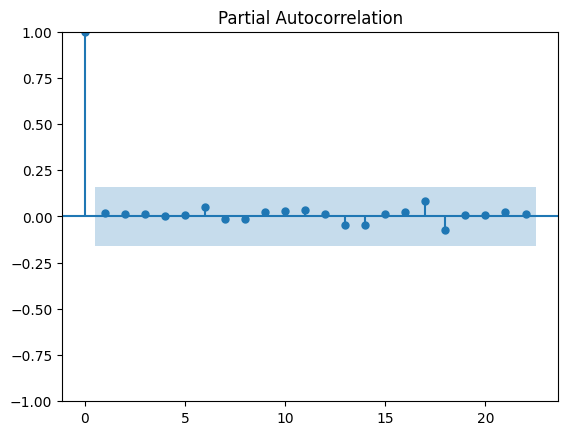

In [548]:
plot_pacf(FinalResult_Moong.resid);

<Axes: xlabel='Date'>

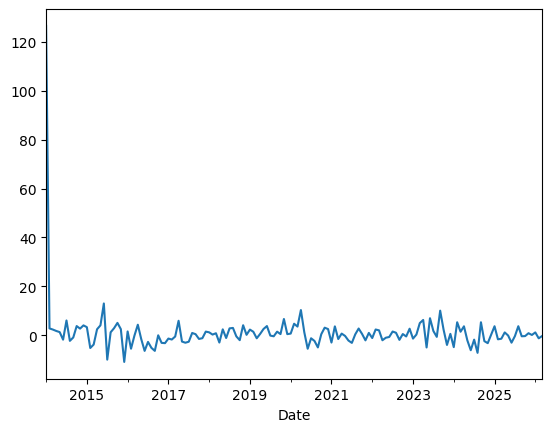

In [549]:
FinalResult_Moong.resid.plot()

<Axes: ylabel='Frequency'>

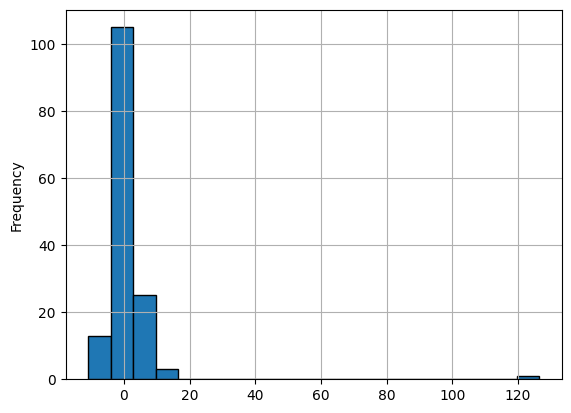

In [550]:
FinalResult_Moong.resid.plot.hist(bins=20,grid=True,edgecolor='k')

##### Normality test

In [551]:
stats.kstest(FinalResult_Moong.resid.values, 'norm') # Kolmogorov-Smirnov test

KstestResult(statistic=np.float64(0.281746397918073), pvalue=np.float64(8.149753471668106e-11), statistic_location=np.float64(2.2983615891176044), statistic_sign=np.int8(-1))

In [552]:
stats.shapiro(FinalResult_Moong.resid)      # Shapiro wilk test

ShapiroResult(statistic=np.float64(0.2820565840707846), pvalue=np.float64(9.085055100206664e-24))

In [553]:
from statsmodels.graphics.tsaplots import quarter_plot, month_plot

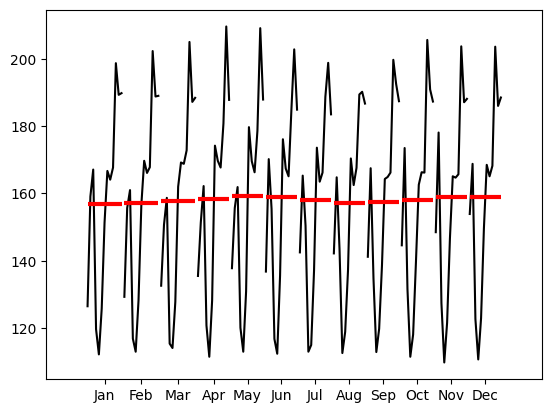

In [554]:
month_plot(data);

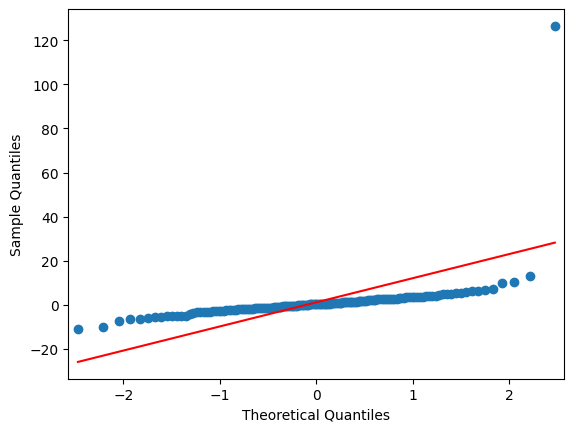

In [555]:
import numpy as np
import statsmodels.api as sm
import pylab


sm.qqplot(FinalResult_Moong.resid, line='s');

In [556]:
sm.stats.diagnostic.acorr_ljungbox(FinalResult_Moong.resid, lags=[30],return_df=True)

,lb_stat,lb_pvalue
30,7.001026,0.999996


# ARIMA-GARCH

In [557]:
sm.stats.diagnostic.het_arch(FinalResult_Moong.resid, nlags=10)

(np.float64(15.30520551618745),
 np.float64(0.12132446584620049),
 1.5846658874929407,
 0.11840744321201042)

In [558]:
resid= FinalResult_Moong.resid

In [559]:
resid

,0
Date,
2014-01-01,126.500000
2014-02-01,2.799371
2014-03-01,2.320914
2014-04-01,1.746077
2014-05-01,1.285946
...,...
2025-11-01,0.834967
2025-12-01,0.120261
2026-01-01,1.160131


In [560]:
resid_train = resid.iloc[:132]
resid_test = resid.iloc[132:]

In [561]:
from arch import arch_model

In [562]:
model_garch = arch_model(resid_train , mean='constant', vol='GARCH', p=1, q=1)
results_garch = model_garch.fit(update_freq = 5)
results_garch.summary()

Iteration:      5,   Func. Count:     31,   Neg. LLF: 1021.5266933192875
Iteration:     10,   Func. Count:     61,   Neg. LLF: 378.5093047450553
Iteration:     15,   Func. Count:     86,   Neg. LLF: 378.4745345123839
Optimization terminated successfully    (Exit mode 0)
            Current function value: 378.47451437732525
            Iterations: 17
            Function evaluations: 95
            Gradient evaluations: 17


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -378.475
Distribution:                  Normal   AIC:                           764.949
Method:            Maximum Likelihood   BIC:                           776.480
                                        No. Observations:                  132
Date:                Mon, Apr 20 2026   Df Residuals:                      131
Time:                        20:04:03   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.2385      0.266      0.897      0.370 [ -0.282,  0.760]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          1.4554      1.057      1.377      0.169 [ -0.617,  3.528]
alpha[1]       0.1161      0.359      0.324      0.746 [ -0.587,  0.819]
beta[1]        0.7330      0.255      2.873  4.061e-03 [  0.233,  1.233]
========================================================================

Covariance estimator: robust
"""

In [563]:
resid_test

,0
Date,
2025-01-01,3.684641
2025-02-01,-1.653923
2025-03-01,-1.425163
2025-04-01,1.159478
2025-05-01,-0.109804
2025-06-01,-3.034967
2025-07-01,-0.350979
2025-08-01,3.689543
2025-09-01,-0.418956


In [564]:
rolling_predictions = []
test_size = 15

for i in range(test_size):
    train = resid[:-(test_size-i)]
    model = arch_model(train, mean='constant', vol='GARCH', p=1, q=1)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

In [565]:
rolling_predictions = pd.Series(rolling_predictions, index=resid.index[-15:])

In [566]:
rolling_predictions

,0
Date,
2025-01-01,3.376777
2025-02-01,3.347731
2025-03-01,3.167398
2025-04-01,3.013789
2025-05-01,2.843389
2025-06-01,2.666747
2025-07-01,2.819768
2025-08-01,2.662762
2025-09-01,2.847960


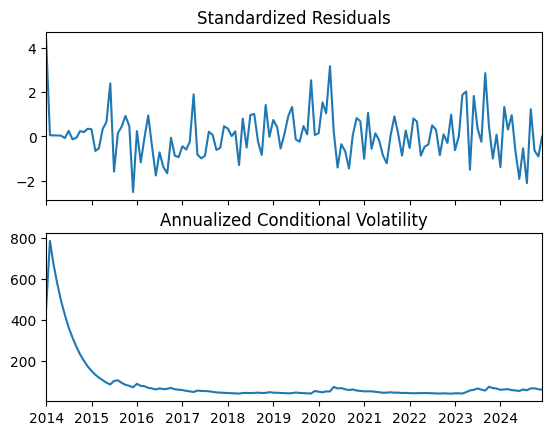

In [567]:
results_garch.plot(annualize='D');

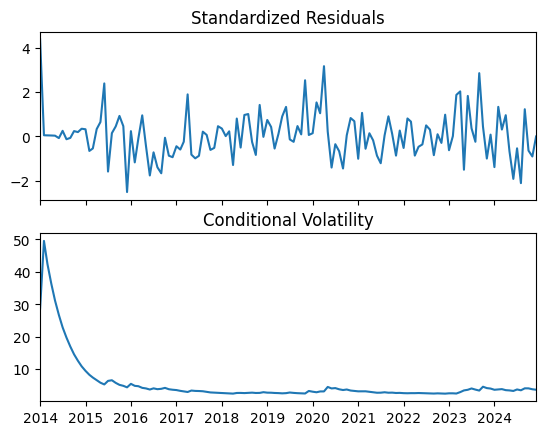

In [568]:
results_garch.plot();

## Normality Check

<Axes: ylabel='Frequency'>

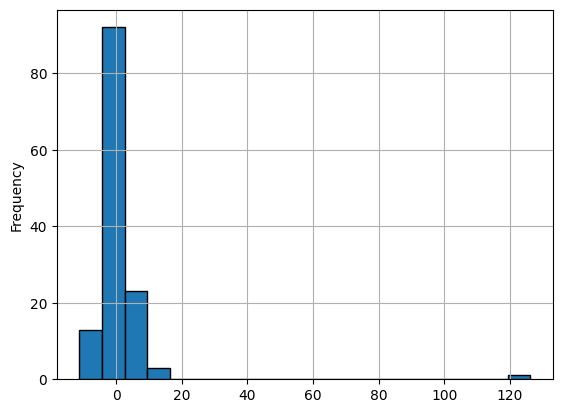

In [569]:
results_garch.resid.plot.hist(bins=20,grid=True,edgecolor='k')

In [570]:
stats.kstest(results_garch.std_resid.values, 'norm') # Kolmogorov-Smirnov test

KstestResult(statistic=np.float64(0.07737555486413839), pvalue=np.float64(0.3883576096595976), statistic_location=np.float64(0.4682587062896068), statistic_sign=np.int8(1))

In [571]:
stats.shapiro(results_garch.std_resid)      # Shapiro wilk test

ShapiroResult(statistic=np.float64(0.9589290871300788), pvalue=np.float64(0.0005254066432552686))

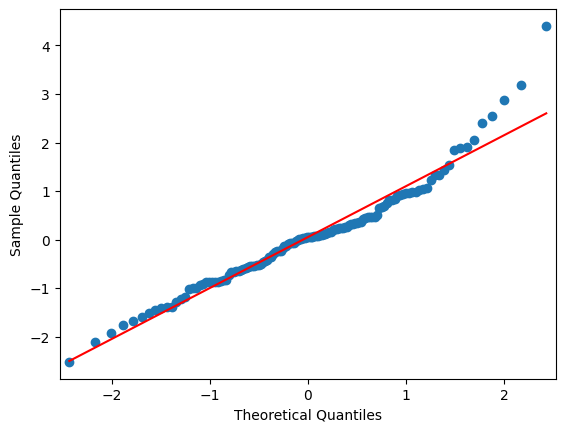

In [572]:
import numpy as np
import statsmodels.api as sm


sm.qqplot(results_garch.std_resid, line='s');

In [573]:
sm.stats.diagnostic.acorr_ljungbox(results_garch.resid, lags=[15], return_df=True)

,lb_stat,lb_pvalue
15,1.656864,0.999992


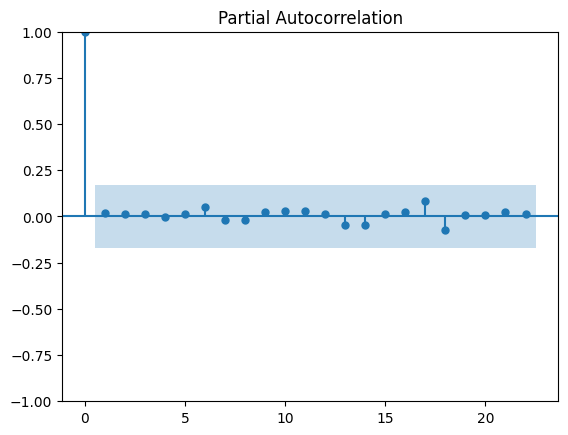

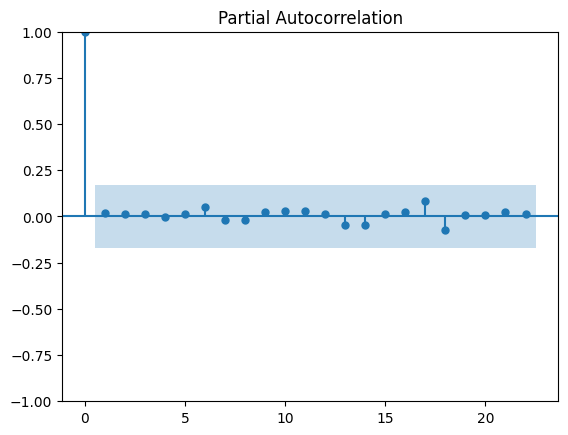

In [574]:
plot_pacf(results_garch.resid)

<Axes: xlabel='Date'>

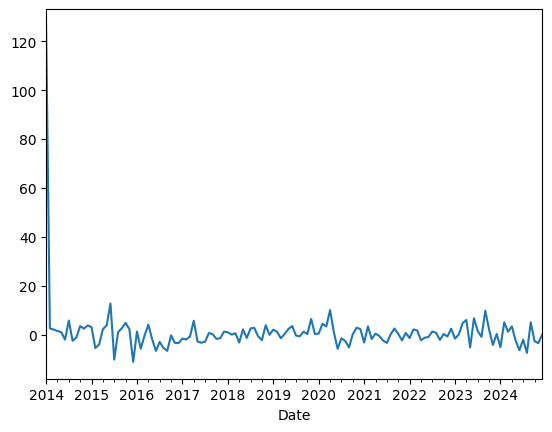

In [575]:
results_garch.resid.plot()

In [576]:
test

,Gram,Moong,Arhar,ARIMA_prediction
Date,,,,
2025-01-01,213.7,189.3,259.1,185.606147
2025-02-01,207.3,188.8,238.8,185.465128
2025-03-01,203.2,187.2,229.8,185.414637
2025-04-01,203.6,187.8,221.8,185.396559
2025-05-01,199.6,187.9,214.8,185.390086
2025-06-01,196.4,184.9,205.6,185.387768
2025-07-01,197.7,183.5,197.6,185.386938
2025-08-01,203.7,186.7,196.2,185.386641
2025-09-01,201.0,187.4,193.4,185.386535


In [577]:
prediction_Moong

,"ARIMA(1,1,0)-predictions"
2025-01-01,185.606147
2025-02-01,185.465128
2025-03-01,185.414637
2025-04-01,185.396559
2025-05-01,185.390086
2025-06-01,185.387768
2025-07-01,185.386938
2025-08-01,185.386641
2025-09-01,185.386535
2025-10-01,185.386497


In [578]:
predicted_mu = result_Moong.forecast()[0]

In [579]:
predicted_mu

np.float64(185.60614690747266)

In [580]:
garch_forecast = results_garch.forecast(horizon=1)

In [581]:
predicted_et = garch_forecast.mean['h.1'].iloc[-1]

In [582]:
predicted_et

np.float64(0.23852389295497228)

In [583]:
prediction = predicted_mu+predicted_et

In [584]:
prediction_GARCH = prediction_Moong+rolling_predictions

In [585]:
prediction_GARCH

,0
2025-01-01,188.982924
2025-02-01,188.812859
2025-03-01,188.582035
2025-04-01,188.410347
2025-05-01,188.233475
2025-06-01,188.054516
2025-07-01,188.206706
2025-08-01,188.049403
2025-09-01,188.234495
2025-10-01,188.083341


In [586]:
rmse(test['Moong'],prediction_GARCH)

np.float64(1.7359987212310015)

In [587]:
prediction_GARCH.shape

(15,)

In [588]:
test['Moong'].shape

(15,)

In [589]:
prediction_Moong.shape

(15,)

In [590]:
mse(test['Moong'],prediction_GARCH)

np.float64(3.0136915601156726)

In [591]:
!pip install diebold_mariano_test

In [592]:
from diebold_mariano_test import cul_d_t,MAE,MSE,cul_DM,cul_P

In [593]:
dm = cul_d_t(MAE,test['Moong'],prediction_Moong,prediction_GARCH)

In [594]:
cul_DM(dm)

np.float64(2.7632195421034003)

In [595]:
cul_P(dm)

np.float64(0.005723425522514399)

In [596]:
MAE(3,test['Moong'],prediction_Moong)

np.float64(1.785362908943796)

In [597]:
dm1=cul_d_t(MAE,test['Moong'],prediction_GARCH,prediction_Moong)

In [598]:
cul_DM(dm1)

np.float64(-2.7632195421034003)

In [599]:
test['GARCH_prediction']= prediction_GARCH

# ARIMA-LSTM

### Lag estimation

In [600]:
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot
from pandas import DataFrame

In [601]:
acf(FinalResult_Moong.resid**2,nlags=12,qstat=True)

(array([ 1.00000000e+00, -2.97761194e-04, -5.19546194e-04, -7.41790821e-04,
        -8.71920551e-04, -7.76376561e-04,  1.25849780e-03, -8.10480395e-04,
        -1.15172947e-03, -3.69639345e-04, -8.46221309e-04, -3.20129264e-04,
        -6.96483204e-04]),
 array([1.33010812e-05, 5.40751391e-05, 1.37771008e-04, 2.54216155e-04,
        3.47189850e-04, 5.93220611e-04, 6.95989247e-04, 9.05010171e-04,
        9.26696243e-04, 1.04118187e-03, 1.05768686e-03, 1.13638983e-03]),
 array([0.99709007, 0.99997296, 0.99999957, 0.99999999, 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        ]))

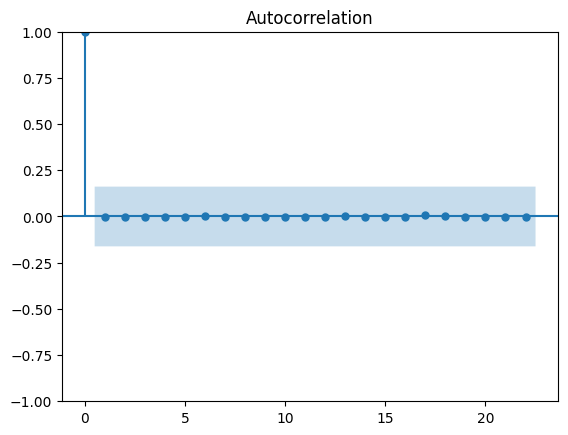

In [602]:
plot_acf(FinalResult_Moong.resid**2);

In [603]:
df['resid'] = FinalResult_Moong.resid**2

In [604]:
df

,Gram,Moong,Arhar,resid
Date,,,,
2014-01-01,103.6,126.5,118.1,16002.250000
2014-02-01,101.7,129.3,118.4,7.836476
2014-03-01,103.5,132.6,119.0,5.386641
2014-04-01,102.8,135.5,120.6,3.048785
2014-05-01,103.1,137.8,121.0,1.653658
...,...,...,...,...
2025-11-01,196.1,188.1,197.8,0.697170
2025-12-01,191.6,188.5,196.6,0.014463
2026-01-01,191.5,189.8,202.2,1.345903


In [605]:
mylist= ['resid']

df1 = df[mylist][1:]
df1.head()

,resid
Date,
2014-02-01,7.836476
2014-03-01,5.386641
2014-04-01,3.048785
2014-05-01,1.653658
2014-06-01,3.255316


In [606]:
dataframe = DataFrame()
for i in range(9,0,-1):
    dataframe['t-'+str(i)] = df1.shift(i).values[:,0]
dataframe['t'] = df1.values[:,0]
print(dataframe.head(10))
dataframe = dataframe[10:]

        t-9       t-8       t-7       t-6       t-5        t-4        t-3  \
0       NaN       NaN       NaN       NaN       NaN        NaN        NaN   
1       NaN       NaN       NaN       NaN       NaN        NaN        NaN   
2       NaN       NaN       NaN       NaN       NaN        NaN        NaN   
3       NaN       NaN       NaN       NaN       NaN        NaN   7.836476   
4       NaN       NaN       NaN       NaN       NaN   7.836476   5.386641   
5       NaN       NaN       NaN       NaN  7.836476   5.386641   3.048785   
6       NaN       NaN       NaN  7.836476  5.386641   3.048785   1.653658   
7       NaN       NaN  7.836476  5.386641  3.048785   1.653658   3.255316   
8       NaN  7.836476  5.386641  3.048785  1.653658   3.255316  36.598551   
9  7.836476  5.386641  3.048785  1.653658  3.255316  36.598551   5.258490   

         t-2        t-1          t  
0        NaN        NaN   7.836476  
1        NaN   7.836476   5.386641  
2   7.836476   5.386641   3.048785  
3   

In [607]:
dataframe.to_csv('lags_12months_features.csv', index=False)

In [608]:
dataframe = pd.read_csv('lags_12months_features.csv', header=0)
array = dataframe.values

In [609]:
X = array[:,0:-1]
y = array[:,-1]

In [610]:
model = RandomForestRegressor(n_estimators=100, random_state=1)
model.fit(X, y)

RandomForestRegressor(random_state=1)

In [611]:
print(model.feature_importances_)

[0.07851956 0.05290734 0.07784189 0.1740458  0.18822785 0.14419378
 0.07645419 0.07157433 0.13623525]


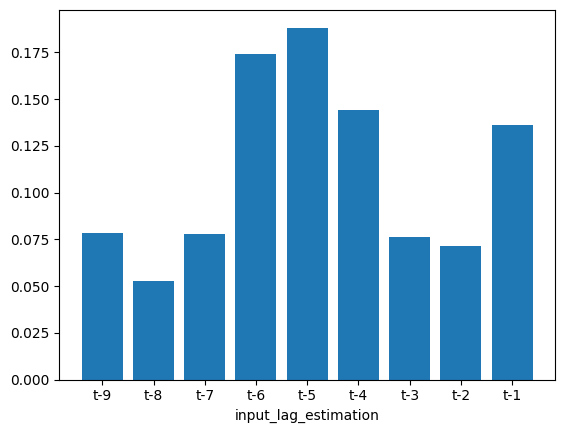

In [612]:
names = dataframe.columns.values[0:-1]
ticks = [i for i in range(len(names))]
pyplot.bar(ticks, model.feature_importances_)
pyplot.xticks(ticks, names)
pyplot.xlabel('input_lag_estimation')
pyplot.show()

In [613]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 146 entries, 2014-02-01 to 2026-03-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   resid   146 non-null    float64
dtypes: float64(1)
memory usage: 2.3 KB


In [614]:
train_resid = df1.iloc[:131]
test_resid = df1.iloc[131:]

In [615]:
train_resid

,resid
Date,
2014-02-01,7.836476
2014-03-01,5.386641
2014-04-01,3.048785
2014-05-01,1.653658
2014-06-01,3.255316
...,...
2024-08-01,51.858800
2024-09-01,28.166300
2024-10-01,5.780415


In [616]:
test_resid

,resid
Date,
2025-01-01,13.576579
2025-02-01,2.735461
2025-03-01,2.031090
2025-04-01,1.344389
2025-05-01,0.012057
2025-06-01,9.211027
2025-07-01,0.123186
2025-08-01,13.612728
2025-09-01,0.175524


In [617]:
from sklearn.preprocessing import MinMaxScaler

In [618]:
scaler = MinMaxScaler()
scaler.fit(train_resid)

MinMaxScaler()

In [619]:
scaled_train = scaler.transform(train_resid)
scaled_test = scaler.transform(test_resid)

In [620]:
scaled_test

array([[8.03764101e-02],
       [1.61920741e-02],
       [1.20218775e-02],
       [7.95629428e-03],
       [6.82854914e-05],
       [5.45303600e-02],
       [7.26221788e-04],
       [8.05904281e-02],
       [1.03608342e-03],
       [7.00651854e-04],
       [4.12446840e-03],
       [8.25287589e-05],
       [7.96525839e-03],
       [9.31546137e-03],
       [6.04146992e-04]])

In [621]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [622]:
# Define the generator
n_input = 1 # how many data will estimate the next time stand value.
n_features = 1

train_generator = TimeseriesGenerator(scaled_train,scaled_train,length=n_input,batch_size=1)

In [623]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.utils import plot_model

In [624]:
model = Sequential()

model.add(LSTM(66, activation='relu', input_shape =(n_input,n_features)))    #relu = rectified linear unit
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

In [625]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 66)             │        17,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            67 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,019 (70.39 KB)

 Trainable params: 18,019 (70.39 KB)

 Non-trainable params: 0 (0.00 B)

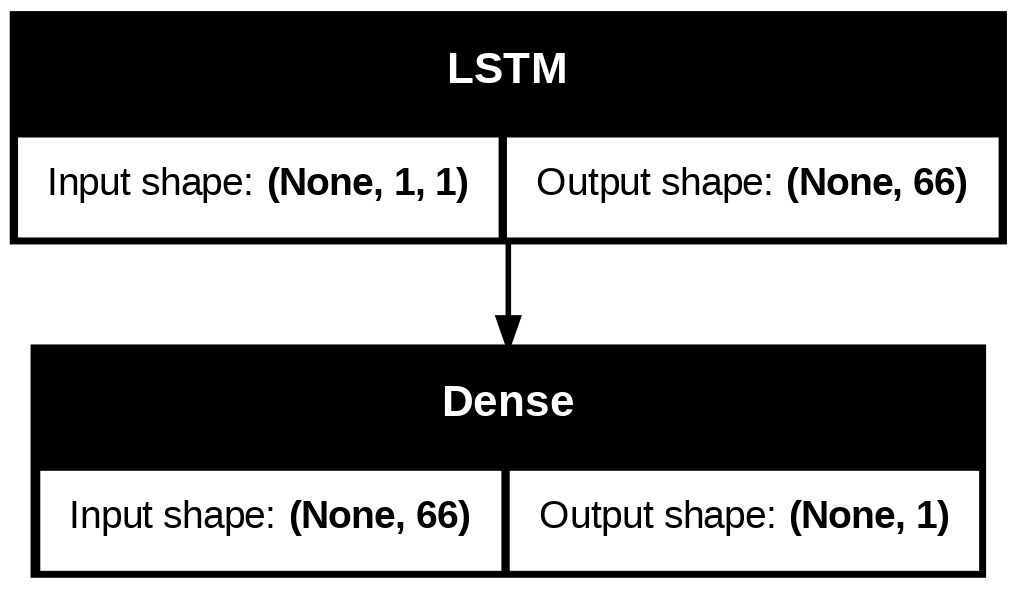

In [626]:
plot_model(model,show_shapes=True)

In [627]:
model.fit(train_generator, epochs=25)

Epoch 1/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0235
Epoch 2/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213
Epoch 3/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213
Epoch 4/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213
Epoch 5/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213
Epoch 6/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0212
Epoch 7/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0212
Epoch 8/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0212
Epoch 9/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0212
Epoch 10/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0212
Epoch 11/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0211
Epoch 12/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0212
Epoch 13/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0211
Epoch 14/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0211
Epoch 15/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

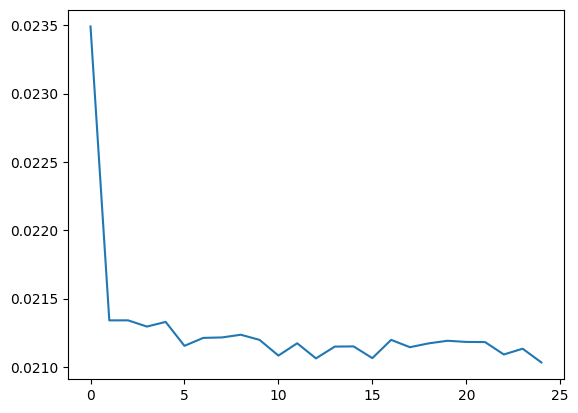

In [628]:
myloss = model.history.history['loss']

plt.plot(range(len(myloss)),myloss)

In [629]:
# Holding my prediction
test_prediction = []

# Last n_input point from the train set
first_eval_batch= scaled_train[-n_input:]

# Reshape this to the RNN format. same as TimeSeriesGenarator
current_batch = first_eval_batch.reshape((1,n_input,n_features))

# How far will we forecast?

for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]

    test_prediction.append(current_pred)

    current_batch= np.append(current_batch[:,1:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [630]:
test_prediction

[array([0.06122857], dtype=float32),
 array([0.06851318], dtype=float32),
 array([0.06932385], dtype=float32),
 array([0.06941101], dtype=float32),
 array([0.06942038], dtype=float32),
 array([0.06942139], dtype=float32),
 array([0.0694215], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32),
 array([0.06942151], dtype=float32)]

In [631]:
true_prediction = scaler.inverse_transform(test_prediction)

In [632]:
true_prediction = true_prediction[:15]


In [633]:
test_resid['resid']

,resid
Date,
2025-01-01,13.576579
2025-02-01,2.735461
2025-03-01,2.031090
2025-04-01,1.344389
2025-05-01,0.012057
2025-06-01,9.211027
2025-07-01,0.123186
2025-08-01,13.612728
2025-09-01,0.175524


In [634]:
test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)'] = true_prediction

In [635]:
test_resid['Prediction Volatility ARIMA-GARCH']= rolling_predictions
test_resid['true Volatility']= resid_test
test_resid.to_csv('Moong volatility.csv')

In [636]:
test['ARIMA-LSTM_Pred']= test['ARIMA_prediction']+test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)']

In [637]:
test

,Gram,Moong,Arhar,ARIMA_prediction,GARCH_prediction,ARIMA-LSTM_Pred
Date,,,,,,
2025-01-01,213.7,189.3,259.1,185.606147,188.982924,195.948541
2025-02-01,207.3,188.8,238.8,185.465128,188.812859,197.037938
2025-03-01,203.2,187.2,229.8,185.414637,188.582035,197.124373
2025-04-01,203.6,187.8,221.8,185.396559,188.410347,197.121016
2025-05-01,199.6,187.9,214.8,185.390086,188.233475,197.116126
2025-06-01,196.4,184.9,205.6,185.387768,188.054516,197.113979
2025-07-01,197.7,183.5,197.6,185.386938,188.206706,197.113168
2025-08-01,203.7,186.7,196.2,185.386641,188.049403,197.112872
2025-09-01,201.0,187.4,193.4,185.386535,188.234495,197.112766


In [638]:
test2=test = test.dropna(subset=['ARIMA-LSTM_Pred'])

test2


,Gram,Moong,Arhar,ARIMA_prediction,GARCH_prediction,ARIMA-LSTM_Pred
Date,,,,,,
2025-01-01,213.7,189.3,259.1,185.606147,188.982924,195.948541
2025-02-01,207.3,188.8,238.8,185.465128,188.812859,197.037938
2025-03-01,203.2,187.2,229.8,185.414637,188.582035,197.124373
2025-04-01,203.6,187.8,221.8,185.396559,188.410347,197.121016
2025-05-01,199.6,187.9,214.8,185.390086,188.233475,197.116126
2025-06-01,196.4,184.9,205.6,185.387768,188.054516,197.113979
2025-07-01,197.7,183.5,197.6,185.386938,188.206706,197.113168
2025-08-01,203.7,186.7,196.2,185.386641,188.049403,197.112872
2025-09-01,201.0,187.4,193.4,185.386535,188.234495,197.112766


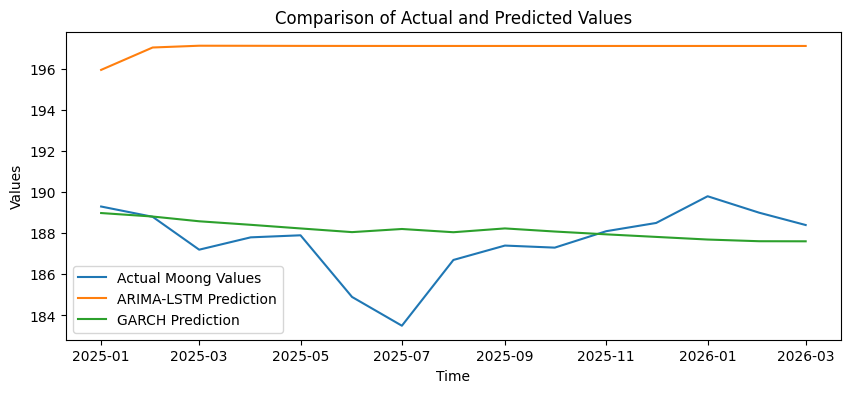

In [639]:
plt.figure(figsize=(10, 4))
plt.plot(test['Moong'], label='Actual Moong Values')
plt.plot(test['ARIMA-LSTM_Pred'], label='ARIMA-LSTM Prediction')
plt.plot(test['GARCH_prediction'], label='GARCH Prediction')

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Values")
plt.title("Comparison of Actual and Predicted Values")
plt.legend()
plt.show()

In [640]:
rmse(test['Moong'],test['ARIMA-LSTM_Pred'])

np.float64(9.544785337549927)

In [641]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [642]:
mean_absolute_percentage_error(test['Moong'],test['ARIMA-LSTM_Pred'])

np.float64(5.013269810345214)

In [643]:
test.to_csv('Moong_result with ARIMA-LSTM Random forecst.csv')

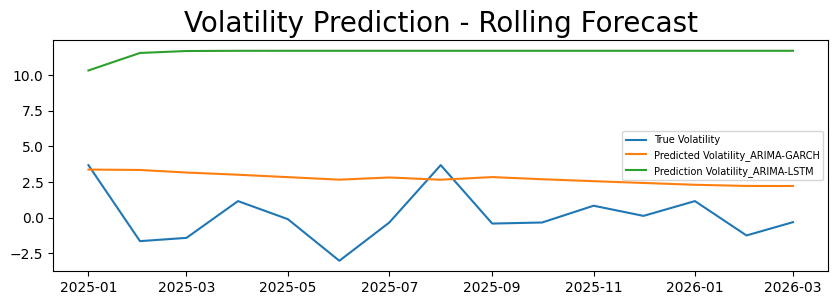

In [644]:
plt.figure(figsize=(10,3))
true, = plt.plot(resid_test)
preds, = plt.plot(rolling_predictions)
pred, = plt.plot(test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)'])
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Volatility', 'Predicted Volatility_ARIMA-GARCH','Prediction Volatility_ARIMA-LSTM'], fontsize=7)